In [21]:
#Load and clean data

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/Womens Clothing E-Commerce Reviews.csv")

# Handle missing review text and categories
df["Review Text"] = df["Review Text"].fillna("")

for col in ["Division Name", "Department Name", "Class Name"]:
    df[col] = df[col].fillna("Unknown")

print("Dataset shape:", df.shape)

Dataset shape: (23486, 11)


In [23]:
#department-level analysis: average rating and share recommended

department_summary = (
    df[df["Department Name"] != "Unknown"]
    .groupby("Department Name")
    .agg(
        Average_Rating=("Rating", "mean"),
        Share_Recommended=("Recommended IND", "mean")
    )
    .reset_index()
)

department_summary["Share_Recommended"] = (
    department_summary["Share_Recommended"] * 100
)

print("Department reviews:", 
      df[df["Department Name"] != "Unknown"].shape[0])

department_summary

Department reviews: 23472


,Department Name,Average_Rating,Share_Recommended
0,Bottoms,4.288760,85.127665
1,Dresses,4.150815,80.819750
2,Intimate,4.280115,85.014409
3,Jackets,4.264535,83.624031
4,Tops,4.172239,81.515094
5,Trend,3.815126,73.949580


In [24]:
#class-level analysis

class_summary = (
    df[df["Class Name"] != "Unknown"]
    .groupby("Class Name")
    .agg(
        Average_Rating=("Rating", "mean"),
        Share_Recommended=("Recommended IND", "mean")
    )
    .reset_index()
)

class_summary["Share_Recommended"] = (
    class_summary["Share_Recommended"] * 100
)

print(
    "Class reviews:",
    df[df["Class Name"] != "Unknown"].shape[0]
)

class_summary

Class reviews: 23472


,Class Name,Average_Rating,Share_Recommended
0,Blouses,4.154020,81.013884
1,Casual bottoms,4.500000,100.000000
2,Chemises,4.000000,100.000000
3,Dresses,4.150815,80.819750
4,Fine gauge,4.260909,83.727273
5,Intimates,4.279221,85.714286
6,Jackets,4.295455,84.517045
7,Jeans,4.360942,88.142982
8,Knits,4.161677,81.767499
9,Layering,4.376712,88.356164


In [25]:
#save the two summary tables

department_summary.to_csv(
    "../outputs/department_summary.csv",
    index=False
)

class_summary.to_csv(
    "../outputs/class_summary.csv",
    index=False
)

print("Saved department_summary.csv")
print("Saved class_summary.csv")

Saved department_summary.csv
Saved class_summary.csv


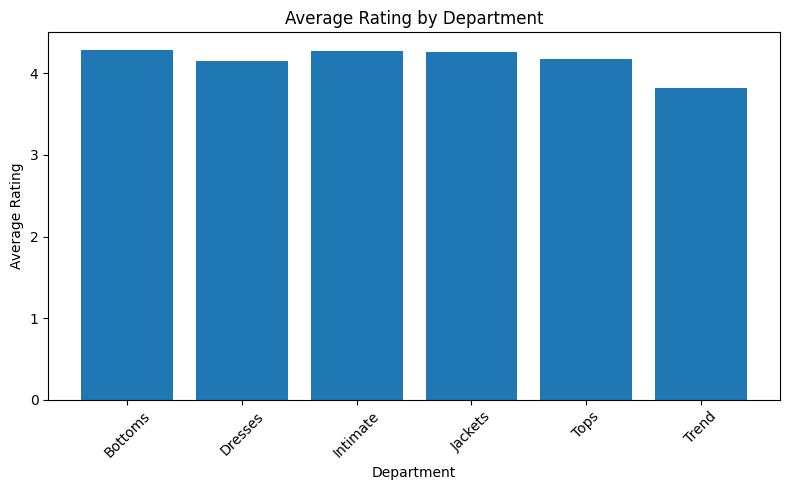

In [26]:
#Department charts

plt.figure(figsize=(8, 5))

plt.bar(
    department_summary["Department Name"],
    department_summary["Average_Rating"]
)

plt.xlabel("Department")
plt.ylabel("Average Rating")
plt.title("Average Rating by Department")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

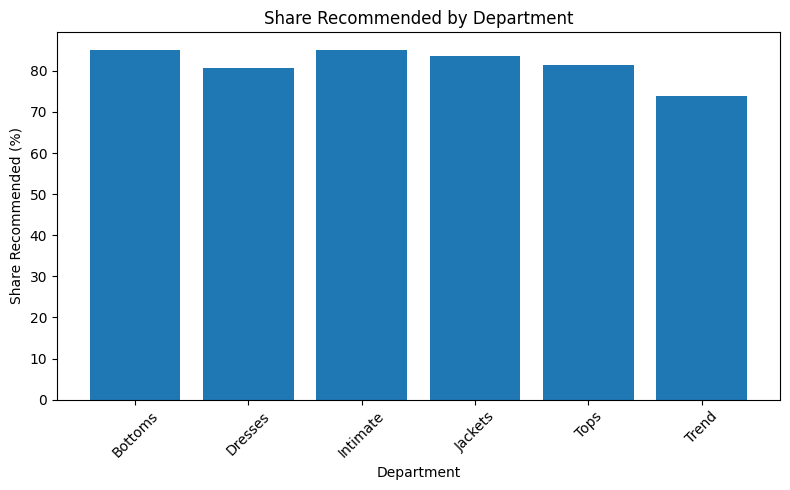

In [27]:
#Share recommended by department

plt.figure(figsize=(8, 5))

plt.bar(
    department_summary["Department Name"],
    department_summary["Share_Recommended"]
)

plt.xlabel("Department")
plt.ylabel("Share Recommended (%)")
plt.title("Share Recommended by Department")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
#Classes with the most 1–2 star ratings

low_rating_counts = (
    df[
        (df["Rating"].isin([1, 2])) &
        (df["Class Name"] != "Unknown")
    ]
    .groupby("Class Name")
    .size()
    .reset_index(name="Low_Rating_Count")
    .sort_values("Low_Rating_Count", ascending=False)
)

low_rating_counts

,Class Name,Low_Rating_Count
1,Dresses,689
6,Knits,506
0,Blouses,348
15,Sweaters,155
11,Pants,124
2,Fine gauge,105
5,Jeans,85
13,Skirts,85
4,Jackets,73
9,Lounge,48


In [29]:
#Save this result

low_rating_counts.to_csv(
    "../outputs/low_rating_counts_by_class.csv",
    index=False
)

print("Saved low_rating_counts_by_class.csv")

Saved low_rating_counts_by_class.csv


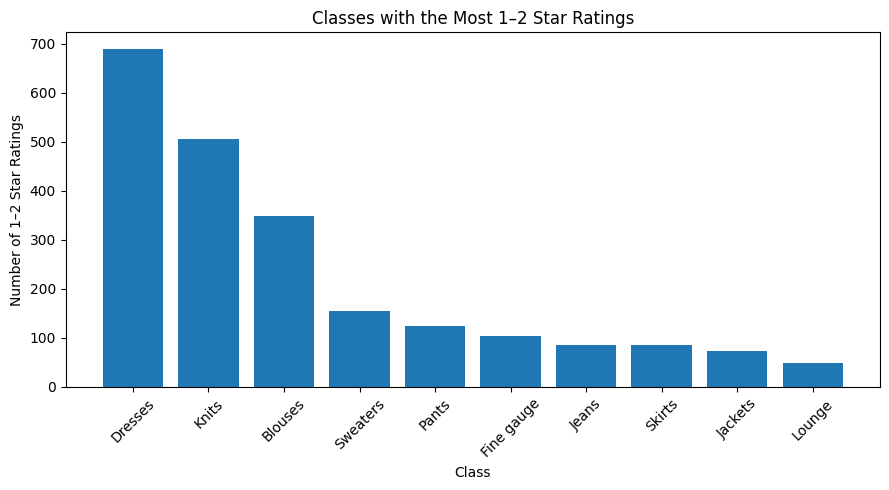

In [30]:
#classes with the most 1–2 star ratings

top_low_ratings = low_rating_counts.head(10)

plt.figure(figsize=(9, 5))

plt.bar(
    top_low_ratings["Class Name"],
    top_low_ratings["Low_Rating_Count"]
)

plt.xlabel("Class")
plt.ylabel("Number of 1–2 Star Ratings")
plt.title("Classes with the Most 1–2 Star Ratings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
#Rating by reviewer age band

def age_band(age):
    if age <= 20:
        return "≤20"
    elif age <= 30:
        return "21–30"
    elif age <= 40:
        return "31–40"
    elif age <= 50:
        return "41–50"
    elif age <= 60:
        return "51–60"
    else:
        return "61+"

df["Age Band"] = df["Age"].apply(age_band)

age_band_summary = (
    df.groupby("Age Band")
    .agg(
        Average_Rating=("Rating", "mean"),
        Review_Count=("Rating", "size")
    )
    .reset_index()
)

age_order = ["≤20", "21–30", "31–40", "41–50", "51–60", "61+"]

age_band_summary["Age Band"] = pd.Categorical(
    age_band_summary["Age Band"],
    categories=age_order,
    ordered=True
)

age_band_summary = age_band_summary.sort_values("Age Band")

age_band_summary

,Age Band,Average_Rating,Review_Count
5,≤20,4.322368,152
0,21–30,4.186127,3186
1,31–40,4.166835,7912
2,41–50,4.166723,5908
3,51–60,4.245952,3891
4,61+,4.287238,2437


In [ ]:
#Save the age-band result
age_band_summary.to_csv(
    "../outputs/age_band_summary.csv",
    index=False
)

print("Saved age_band_summary.csv")

Saved age_band_summary.csv


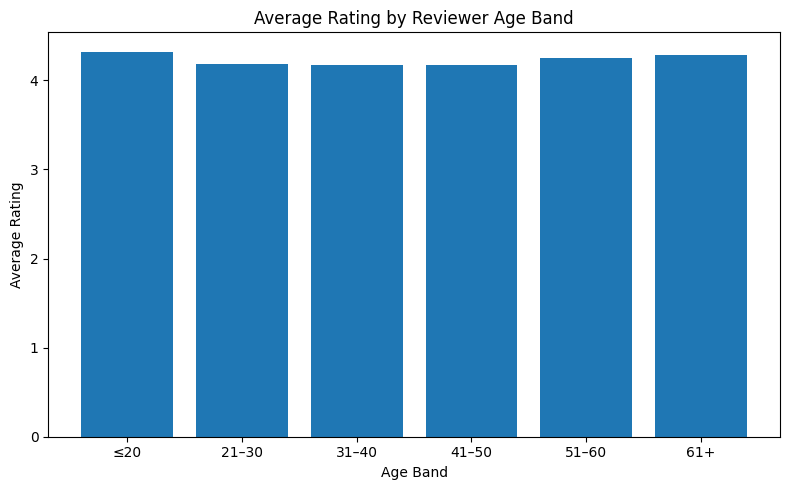

In [33]:
#Final Part B chart: Average rating by age band

plt.figure(figsize=(8, 5))

plt.bar(
    age_band_summary["Age Band"].astype(str),
    age_band_summary["Average_Rating"]
)

plt.xlabel("Age Band")
plt.ylabel("Average Rating")
plt.title("Average Rating by Reviewer Age Band")
plt.tight_layout()
plt.show()


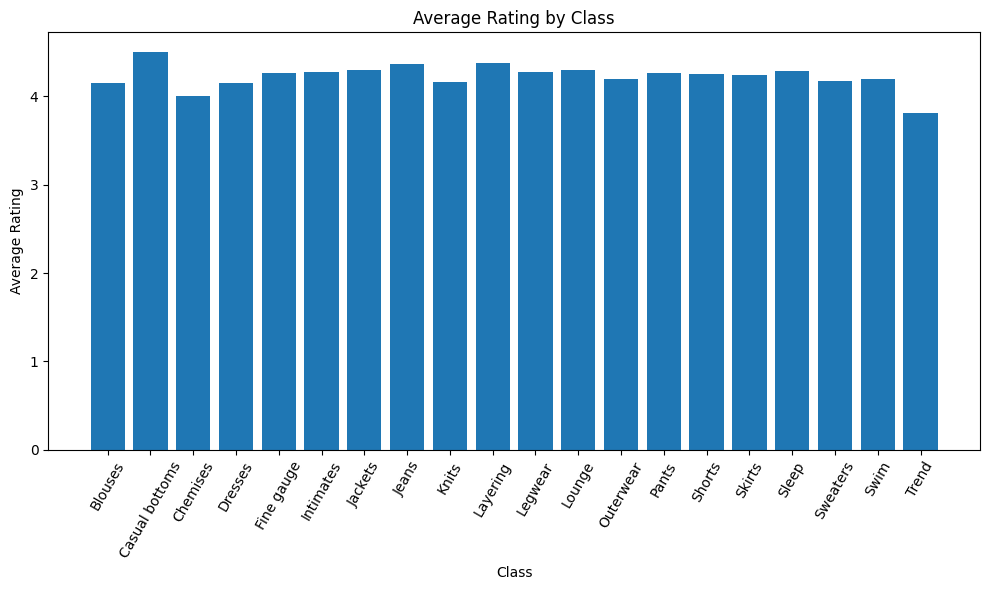

In [34]:
#Average Rating by Class

plt.figure(figsize=(10, 6))

plt.bar(
    class_summary["Class Name"],
    class_summary["Average_Rating"]
)

plt.xlabel("Class")
plt.ylabel("Average Rating")
plt.title("Average Rating by Class")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

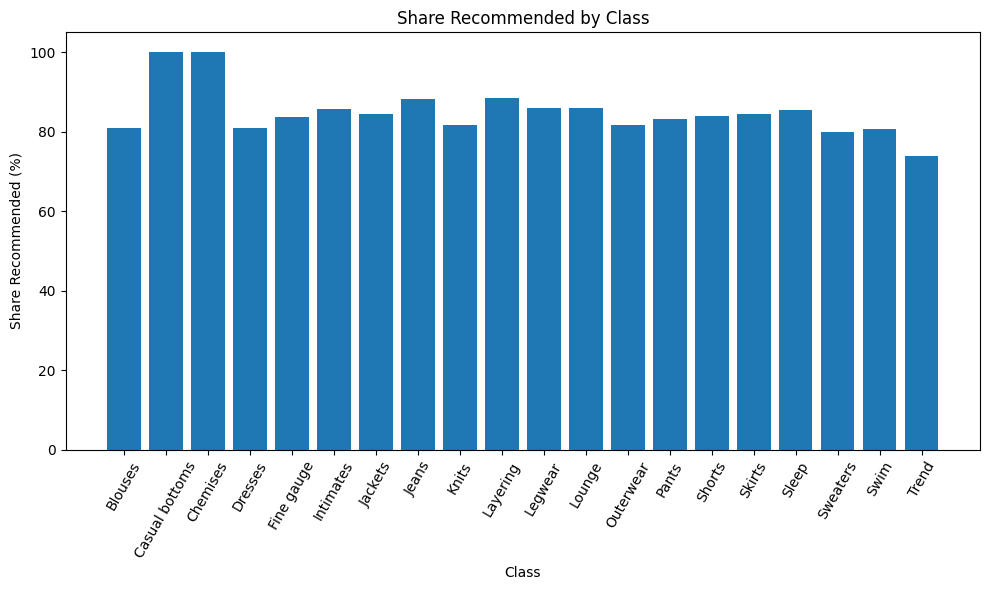

In [35]:
#Share Recommended by Class

plt.figure(figsize=(10, 6))

plt.bar(
    class_summary["Class Name"],
    class_summary["Share_Recommended"]
)

plt.xlabel("Class")
plt.ylabel("Share Recommended (%)")
plt.title("Share Recommended by Class")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()